# Origin of the Mexican-hat connectivity profile

Theory-side companion to the data analysis: how a center-surround `J(Δx)` arises from the geometry of the stored correlations. Produces Fig 13 (`mexican_hat_origin.pdf`, final cell) and Fig 20 (`asymmetric_models.png`, `SAVE_FIGURES`-gated producer below).

In [ ]:
# Regeneration switches (default off so a normal run cannot overwrite committed figures/caches):
SAVE_FIGURES = False


import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from ring import style

## DMFT on ring geometries with variable shape (Fig 20)

Mean-field dynamics for `Gamma_x` drawn from a ring deformed by a shape parameter `f`, run from several initial conditions. Shows that the deformed geometries still relax onto a continuous attractor, and how `Γ_x`, `Γ_φ`, `J`, `U` change with `f`. The cell-top `np.random.seed(42)` (fix F6) pins the initial-condition noise. The `plt.savefig("asymmetric_models.png")` at the bottom is **guarded by `SAVE_FIGURES`** (default `False`): the pre-F6 panel is the canonical baseline (TIER-3), so a post-F6 re-run gives a statistically equivalent but not bit-identical figure.

In [ ]:
np.random.seed(42)

def generate_pts(N_theta, f=0.):
    """Generate points for Gamma_x with variable shape parameter f"""
    theta = np.linspace(0, 2*np.pi, N_theta, endpoint=False)
    r = 1 + f * np.sin(2*theta)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    pts = np.column_stack([x, y])
    return pts, theta

def phi(x, beta):
    """Activation function"""
    return 1. + erf(beta*np.sqrt(np.pi)*x/2.)

def G(C_11, C_22, C_12, beta):
    """DMFT self-consistency function"""
    return 1. + (2./np.pi)*np.arctan( 
        (beta**2)*C_12 / np.sqrt( 
            ((beta**2)*C_11 + (2./np.pi))*((beta**2)*C_22 + (2./np.pi)) - ((beta**2)*C_12)**2 
        ) 
    )

tau = 0.050
def run_dmft_simulation(Gamma_x, beta, lamda, T, dt, n_init_conditions, init_noise):
    """Run DMFT simulation with multiple initial conditions"""
    N_theta = Gamma_x.shape[0]
    N_t = int(T / dt)
    
    # Compute matrices using numerically stable least squares
    Gamma_phi = G(np.diag(Gamma_x)[None, :], np.diag(Gamma_x)[:, None], Gamma_x, beta=beta)
    # Matrix form of the continuum kernel C_phi + 2 pi lamda delta(theta - theta'):
    # on an N_theta-point grid the delta is (N_theta / 2 pi) I, so the ridge enters as
    # N_theta * lamda. Same lamda, same convention, as regression.compute_J.
    Gamma_phi_reg = Gamma_phi + np.eye(N_theta)*(N_theta*lamda)
    Gamma_phi_inv = np.linalg.inv(Gamma_phi_reg)

    J = Gamma_x @ Gamma_phi_inv
    U = Gamma_phi_inv @ Gamma_x @ Gamma_phi_inv
    
    # Storage for trajectories
    trajectories = []
    init_conditions = []
    
    # Run simulations with different initial conditions
    for i in range(n_init_conditions):
        init_frac = i / n_init_conditions
        init_idx = int(init_frac * N_theta)
        
        m_tilde = np.zeros((N_t, N_theta))
        m_tilde[0] = Gamma_phi[init_idx] + np.random.randn(N_theta)*init_noise
        
        for t_idx in range(1, N_t):
            C_11 = np.diag(Gamma_x)
            C_22 = (m_tilde[t_idx-1] @ (U @ m_tilde[t_idx-1])).item()
            C_12 = J @ m_tilde[t_idx-1]
            dm_dt = (-m_tilde[t_idx-1] + G(C_11, C_22, C_12, beta=beta)) / tau
            m_tilde[t_idx] = m_tilde[t_idx-1] + dt*dm_dt
        
        trajectories.append(m_tilde)
        init_conditions.append(Gamma_phi[init_idx])
    
    return trajectories, init_conditions, J, U, Gamma_phi

def plot_dmft_results(f_values, N_theta, beta, lamda, T, dt, n_init_conditions, init_noise):
    """Plot DMFT results for different f values"""
    # Create figure with custom layout for each f value
    # Layout: ABCFF
    #         -DEFF
    # where A=geom, B,C,D,E=matrices, F=tuning curves
    
    fig = plt.figure(figsize=(style.FULL_W, 6.5)) #2*len(f_values)))
    
    # Use a cyclic colormap
    colors = style.ANGLE_CMAP(np.linspace(0, 1, n_init_conditions))  # n_init_conditions + wrap around
    
    # Compute every row first, so the four matrix families can share one colour
    # scale each. Previously all twelve imshow panels autoscaled independently, which
    # made intensities incomparable across f in a figure whose point is how these
    # kernels change with f. One scale per quantity, since Gamma^x, Gamma^phi, J and U
    # are different objects and a single scale across all four would be meaningless.
    runs = []
    for f in f_values:
        pts, theta = generate_pts(N_theta, f=f)
        Gamma_x = pts @ pts.T
        trajectories, init_conditions, J, U, Gamma_phi = run_dmft_simulation(
            Gamma_x, beta, lamda=lamda, T=T, dt=dt, n_init_conditions=n_init_conditions, init_noise=init_noise)
        runs.append(dict(f=f, pts=pts, theta=theta, Gamma_x=Gamma_x, Gamma_phi=Gamma_phi,
                         J=J, U=U, trajectories=trajectories, init_conditions=init_conditions))

    # A robust shared limit, not the maximum. At f=0.3 the near-null modes of
    # Gamma_phi put a few large outliers into J and U, and scaling to the max
    # would leave the f=0 and f=0.15 panels blank. The 99.5th percentile keeps
    # structure visible in every row; the handful of outliers saturate, which is
    # the normal trade and is what the colour bars show.
    # Gamma^x and Gamma^phi have comparable amplitude across f, so they share one
    # scale each and become directly comparable down their column. J and U do not:
    # at f=0.3 the near-null modes of Gamma^phi make them more than an order of
    # magnitude larger, so a shared scale leaves the f=0 and f=0.15 panels blank.
    # Those two keep a per-row scale and every panel carries its own colour bar, so
    # the amplitudes are readable rather than implied.
    _lim = {k: float(np.percentile(np.abs(np.concatenate([np.ravel(r[k]) for r in runs])), 99.5))
            for k in ('Gamma_x', 'Gamma_phi')}

    for row, _r in enumerate(runs):
        f = _r['f']
        pts, theta = _r['pts'], _r['theta']
        Gamma_x, Gamma_phi = _r['Gamma_x'], _r['Gamma_phi']
        J, U = _r['J'], _r['U']
        trajectories, init_conditions = _r['trajectories'], _r['init_conditions']

        # Create subplot grid for this f value
        base_pos = row * 2  # Two rows per f value
        
        # A: Geometry (top-left)
        ax_geom = plt.subplot2grid((len(f_values)*2, 5), (base_pos, 0), rowspan=2, colspan=1)
        theta_normalized = theta / (2*np.pi)
        ax_geom.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.8, c=theta_normalized, cmap=style.ANGLE_CMAP)
        ax_geom.set_title(f'Geometry (f={f})', pad=-2)
        ax_geom.set_aspect('equal')
        
        # B: Gamma_x (top row, second column)
        ax_gamma_x = plt.subplot2grid((len(f_values)*2, 5), (base_pos, 1), rowspan=1, colspan=1)
        im_gamma_x = ax_gamma_x.imshow(Gamma_x, cmap=style.DIVERGING_CMAP, aspect='equal',
                                       vmin=-_lim['Gamma_x'], vmax=_lim['Gamma_x'])
        ax_gamma_x.set_title(f'$\\Gamma^x$ (f={f})')
        
        # C: Gamma_phi (top row, third column)
        ax_gamma_phi = plt.subplot2grid((len(f_values)*2, 5), (base_pos, 2), rowspan=1, colspan=1)
        im_gamma_phi = ax_gamma_phi.imshow(Gamma_phi, cmap=style.DIVERGING_CMAP, aspect='equal',
                                           vmin=-_lim['Gamma_phi'], vmax=_lim['Gamma_phi'])
        ax_gamma_phi.set_title(f'$\\Gamma^\\phi$ (f={f})')
        
        # F: Tuning curves (spans columns 3-4, both rows)
        ax_tuning = plt.subplot2grid((len(f_values)*2, 5), (base_pos, 3), rowspan=2, colspan=2)
        theta_vals = np.arange(N_theta)*2*np.pi/N_theta
        for i, (traj, init_cond) in enumerate(zip(trajectories, init_conditions)):
            color = colors[i]
            ax_tuning.plot(theta_vals, traj[0], c=color, alpha=0.15, lw=1, label='Initial' if i == 0 else '')
            ax_tuning.plot(theta_vals, init_cond, c=color, lw=3, alpha=0.2)
            ax_tuning.plot(theta_vals, traj[-1], c=color, alpha=1, lw=0.75, ls='--', label='Final' if i == 0 else '')
        ax_tuning.set_xticks([0, np.pi, 2*np.pi])
        ax_tuning.set_xticklabels(["$0$", "$\\pi$", "$2\\pi$"])
        ax_tuning.set_title(f'$\\tilde{{m}}(\\theta)$ (f={f})', pad=-2)
        
        # D: J matrix (bottom row, second column)
        ax_j = plt.subplot2grid((len(f_values)*2, 5), (base_pos+1, 1), rowspan=1, colspan=1)
        _jl = float(np.percentile(np.abs(J), 99.5))
        im_j = ax_j.imshow(J, cmap=style.DIVERGING_CMAP, aspect='equal',
                           vmin=-_jl, vmax=_jl)
        ax_j.set_title(f'$\\mathcal{{J}}$ (f={f})')
        
        # E: U matrix (bottom row, third column)
        ax_u = plt.subplot2grid((len(f_values)*2, 5), (base_pos+1, 2), rowspan=1, colspan=1)
        _ul = float(np.percentile(np.abs(U), 99.5))
        im_u = ax_u.imshow(U, cmap=style.DIVERGING_CMAP, aspect='equal',
                           vmin=-_ul, vmax=_ul)
        ax_u.set_title(f'$\\mathcal{{U}}$ (f={f})')

        for ax in (ax_gamma_phi, ax_gamma_x, ax_j, ax_u):
            ax.set_xticks([])
            ax.set_yticks([])

        # Panel letters. Drawn once, on the first f block. Each block repeats the
        # same six panels and every panel title already carries its own f, so one
        # set of six letters names all eighteen axes.
        if row == 0:
            style.panel_letter(ax_geom, 'a', x=-0.06)
            style.panel_letter(ax_gamma_x, 'b', x=-0.1)
            style.panel_letter(ax_gamma_phi, 'c', x=-0.1)
            style.panel_letter(ax_tuning, 'd')
            style.panel_letter(ax_j, 'e', x=-0.1)
            style.panel_letter(ax_u, 'f', x=-0.1)

        # J and U are scaled per row, so each needs its own bar. Gamma^x and
        # Gamma^phi share a scale, so one bar under the last row serves all three.
        _bars = [(ax_j, im_j), (ax_u, im_u)]
        if row == len(runs) - 1:
            _bars += [(ax_gamma_x, im_gamma_x), (ax_gamma_phi, im_gamma_phi)]
        for _ax, _im in _bars:
            _cb = fig.colorbar(_im, ax=_ax, orientation='horizontal',
                               fraction=0.05, pad=0.09, shrink=0.95, extend='both')
            # Two end ticks only, written compactly. Matplotlib's default offset
            # text sits at the bar's right edge and collided with the title of the
            # row below, so the exponent goes into each tick label instead.
            _lo, _hi = _im.get_clim()
            _cb.set_ticks([_lo, _hi])
            _cb.ax.set_xticklabels([f'{_lo:.0e}'.replace('e-0', 'e-'),
                                    f'{_hi:+.0e}'.replace('e-0', 'e-')])
            _cb.ax.tick_params(labelsize=5, pad=1)
    
    fig.subplots_adjust(hspace=0.75)

# Run the analysis for the requested f values.
#
# lamda is 1e-6 here, NOT the 1e-8 used everywhere else, and the difference is
# deliberate. Gamma_x on this page is pts @ pts.T for points on a 2D ring, so it is
# exactly RANK 2, and J and U inherit that rank. Their size is therefore set entirely
# by how (Gamma_phi + N_theta*lamda)^-1 acts on two directions, and U applies that
# inverse TWICE. Gamma_phi has 19 eigenvalues above 1e-3 but 29 above 1e-5, so
# dropping to 1e-8 admits ten near-null modes whose amplification puts large outliers
# into U. At f=0.3 that raised |U|max by 11.5x and |J|max by 3.5x. The imshow panels
# below autoscale, so those outliers set the colour limits and wash the real structure
# out. Elsewhere Gamma_phi is the empirical (1/N) Phi Phi^T of N sampled tuning curves
# and its small eigenvalues carry genuine sampling structure, which is what 1e-8 is
# sized for. This is a different object, so it gets a different ridge.
#
# 1e-6 x N_theta = 1e-3, the additive constant this cell used before the 2026-07-31
# rescale, so J and U here are bit-identical to the published figure.
f_values = [0.0, 0.15, 0.3]
plot_dmft_results(f_values, N_theta=1000, beta=2.5, lamda=1e-6, T=30, dt=tau / 10., n_init_conditions=10, init_noise=0.01)

if SAVE_FIGURES:
    plt.savefig("../figures/asymmetric_models.png", bbox_inches='tight', dpi=500)

## Finite-N check: sample tuning curves and simulate

Sanity check that the mean-field picture survives at finite `N`: sample `X` from the GP with covariance `Gamma_x`, fit `J` by regularized regression against `Φ`, and integrate the network from a perturbed point on the manifold. The two cells below are the diagnostics (trajectories, and the residual `J Φ − X`). The `np.random.randn` draws here are covered only transitively by the seed in the cell above, so an out-of-order run gives a different `X`.

In [365]:
N_theta = 500
beta = 3.5
f = 0.05
pts, theta = generate_pts(N_theta, f=f)
Gamma_x = pts @ pts.T

L = np.linalg.cholesky(Gamma_x + np.eye(N_theta)*1e-12)
N = 2500
Z = np.random.randn(N_theta, N)
X = L @ Z
Phi = phi(X, beta=beta)

Gamma_phi = (Phi @ Phi.T)/N
# Dual-form ridge, matching regression.compute_J: K = Phi Phi^T / N + lamda * N_theta * I.
lamda = 1e-8
Gamma_phi_reg = Gamma_phi + np.eye(N_theta)*(lamda*N_theta)
J = (1./N) * X.T @ np.linalg.inv(Gamma_phi_reg) @ Phi

T = 100
dt = 0.1
N_t = int(T / dt)

X_dyn = np.zeros((N_t, N))

init_frac = 0.3
init_idx = int(N_theta*init_frac)
X_dyn[0] = X[init_idx] + np.random.randn(N)*0.1

for i in range(1, N_t):
    dxdt = -X_dyn[i-1] + J @ phi(X_dyn[i-1], beta=beta)
    X_dyn[i] = X_dyn[i-1] + dt * dxdt


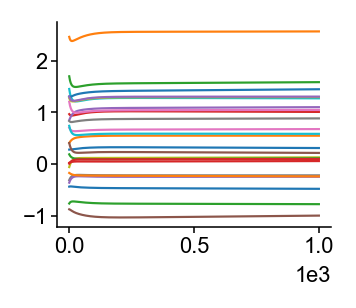

In [373]:
plt.plot(X_dyn[:, ::100])
plt.show()

In [297]:
J @ Phi[0] - X[0]

array([ 0.00124911,  0.00061452,  0.00061656, ..., -0.00148887,
        0.00015751, -0.00064388])

## Fourier-domain relation between `Γ_x`, `Γ_φ` and `J`

Exploratory: working on the translation-invariant (circulant) case, where `J` is diagonal in the Fourier basis and `Ĵ = Γ̂_x / Γ̂_φ`. The cells here are scratch plots of the three spectra and hand-fit guesses; they informed the final figure but are not themselves figure producers.

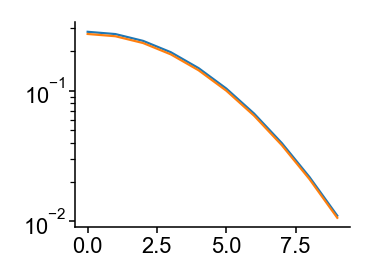

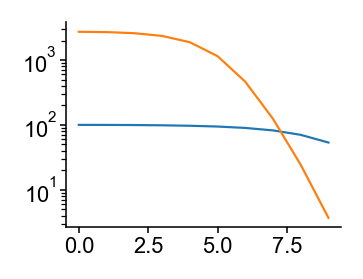

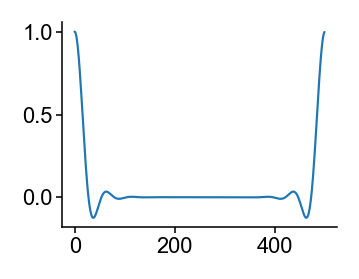

In [707]:
sigma = 5
beta = 0.1

n = np.arange(251)
Gamma_x_ft = np.exp(-(n / sigma)**2) * np.sqrt(1./(4*np.pi))
Gamma_x = np.fft.irfft(Gamma_x_ft, norm='forward')
Gamma_phi = G(Gamma_x[0], Gamma_x[0], Gamma_x, beta=beta) - 1
Gamma_phi_ft = np.fft.rfft(Gamma_phi, norm='forward')
J_ft = Gamma_x_ft / (Gamma_phi_ft + 1e-4)
J = np.fft.irfft(J_ft,  norm='forward')

plt.plot(Gamma_x_ft.real[:10])
plt.plot(Gamma_phi_ft.real[:10] / beta**2)
plt.yscale('log')
plt.show()

plt.plot(J_ft.real[:10])
J_ft_fake = (3e3 * 1./(1 + 0.1*np.exp((n[:15]/3)**2)))
J_ft_fake = np.concatenate((J_ft_fake, np.zeros(len(n)-len(J_ft_fake))))
plt.plot(J_ft_fake[:10])
plt.yscale('log')
plt.show()

plt.plot(J/J[0])
plt.show()




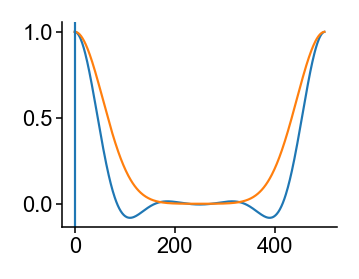

In [686]:
plt.plot(J / J[0])
plt.plot(Gamma_phi / Gamma_phi[0])
plt.axvline(1./sigma)

(0.0, 20.0)

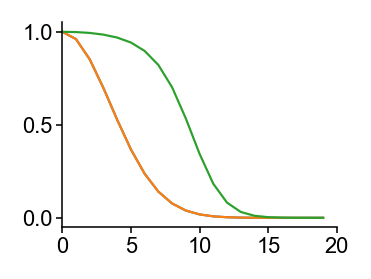

In [708]:
plt.plot(Gamma_x_ft[:20] / Gamma_x_ft[0])
plt.plot(Gamma_phi_ft[:20] / Gamma_phi_ft[0])
plt.plot(J_ft[:20] / J_ft[0])
plt.xlim(0, 20)

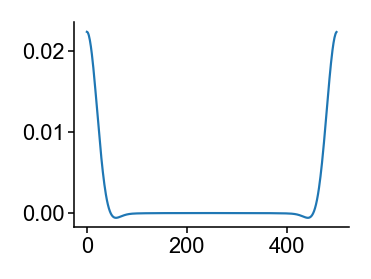

In [724]:
guess_ft = np.exp(-0.01*n**2.5)
plt.plot(np.fft.irfft(guess_ft))

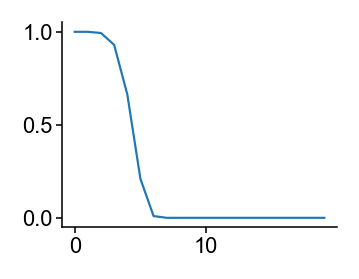

In [718]:
plt.plot(guess_ft[:20])

## Cumulant expansion of the correlation profiles

Reformulates the same ratio in terms of the second and fourth cumulants of `Γ_x` and `Γ_φ` treated as distributions: `Ĵ ≈ exp(−½(κ₂ˣ − κ₂^φ)k² − (1/24)κ₄^φ k⁴)`. The cells here develop the approximation on the discrete circle; the figure cell below redoes it on a fine real-line grid, which is the form used for the figure.

In [829]:
sigma = 20
beta = 10

n = np.arange(50001)
Gamma_x_ft = np.exp(-(n / sigma)**2) * np.sqrt(1./(4*np.pi))
Gamma_x = np.fft.irfft(Gamma_x_ft, norm='forward')
Gamma_phi = G(Gamma_x[0], Gamma_x[0], Gamma_x, beta=beta) - 1
Gamma_phi_ft = np.fft.rfft(Gamma_phi, norm='forward')
J_ft = Gamma_x_ft / (Gamma_phi_ft + 1e-4)
J = np.fft.irfft(J_ft,  norm='forward')

P_x = np.roll(Gamma_x / Gamma_x.sum(), len(n))
P_phi = np.roll(Gamma_phi / Gamma_phi.sum(), len(n))
x = (np.arange(len(P_x)) * 2*np.pi / len(P_x)) - np.pi
x = np.roll(x, 1)

k2_x = P_x @ x**2
k2_phi = P_phi @ x**2
k4_x = (P_x @ x**4) - 3*k2_x**2
k4_phi = (P_phi @ x**4) - 3*k2_phi**2

In [830]:
k2_x, k2_phi

(0.004999999999999243, 0.004367956008689082)

In [831]:
k4_x, k4_phi

(-6.1339144484182095e-15, 6.298563773522122e-06)

(0.0, 5000.0)

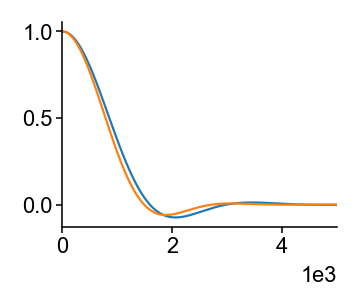

In [835]:
J_ft = Gamma_x_ft / (Gamma_phi_ft + 1e-12)
J = np.fft.irfft(J_ft)
J /= J[0]
plt.plot(J)

J_guess_ft = np.exp(-0.5*(k2_x - k2_phi)*n**2 - (1./24)*k4_phi*n**4)
J_guess = np.fft.irfft(J_guess_ft)
J_guess /= J_guess[0]
plt.plot(J_guess)
plt.xlim(0, 5000)

4.0 3.5709409411798276 0.0 3.401763738214683


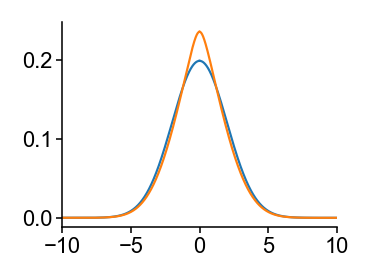

(-15.0, 15.0)

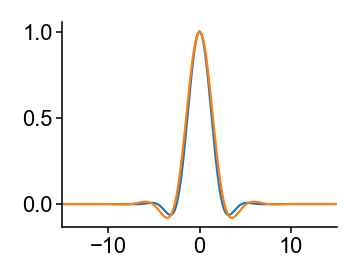

In [1028]:
beta = 5.
ell = 2.

L = 50
dx = 0.01
N_x = int(2*L / dx)
x = (np.arange(N_x) * dx) - L
x = np.roll(x, -N_x//2)

Gamma_x = np.exp(-0.5 * (x / ell)**2)
Gamma_phi = G(1., 1., Gamma_x, beta=beta) - 1

P_x = Gamma_x / (Gamma_x.sum() * dx)
P_phi = Gamma_phi / (Gamma_phi.sum() * dx)

k2_x, k2_phi = P_x @ (x**2 * dx), P_phi @ (x**2 * dx)
k4_x, k4_phi = (P_x @ (x**4 * dx)) - 3*k2_x**2, (P_phi @ (x**4 * dx)) - 3*k2_phi**2

print(k2_x, k2_phi, k4_x, k4_phi)

P_x_ = P_x.copy()
P_phi_ = P_phi.copy()
P_x_[N_x//2] = np.nan
P_phi_[N_x//2] = np.nan
plt.plot(x, P_x_)
plt.plot(x, P_phi_)
plt.xlim(-10, 10)
plt.show()


J = np.fft.irfft(np.fft.rfft(P_x) / (np.fft.rfft(P_phi) + 1e-8))

k = np.fft.rfftfreq(N_x, d=dx/(2*np.pi))
J_guess = np.fft.irfft(np.exp((-(1./2.)*(k2_x - k2_phi)*(k**2) - (1./24.)*k4_phi*(k**4)))) / dx

#J_guess = np.fft.irfft(np.exp(-0.5*(k**2))) / dx [old comment, but keep!]

J_guess[N_x//2] = np.nan
J[N_x//2] = np.nan
plt.plot(x, J_guess / J_guess[0])
plt.plot(x, J / J[0])
plt.xlim(-15, 15)


## Figure 13 — origin of the Mexican hat

The published figure. Sweeps the Fourier decay scale `σ` across three values and compares the exact `J(Δs)` (red) against the 2nd-order, 4th-order, and combined cumulant approximations. The `κ₄^φ > 0` term is what produces the negative surround — the point of the figure. Saves `mexican_hat_origin.pdf`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

beta = 2
ell_values = [3., 2., 1.]

L = 50
dx = 0.01
N_x = int(2*L / dx)
x = (np.arange(N_x) * dx) - L
x = np.roll(x, -N_x//2)

fig, axes = plt.subplots(2, 3, figsize=(style.FULL_W, 3.6), sharey='row')

for col, ell in enumerate(ell_values):
    # Calculate Gamma functions
    Gamma_x = np.exp(-0.5 * (x / ell)**2)
    Gamma_phi = G(1., 1., Gamma_x, beta=beta) - 1
    
    # Calculate probability distributions
    P_x = Gamma_x / (Gamma_x.sum() * dx)
    P_phi = Gamma_phi / (Gamma_phi.sum() * dx)
    
    # Calculate cumulants
    k2_x = P_x @ (x**2 * dx)
    k2_phi = P_phi @ (x**2 * dx)
    k4_x = (P_x @ (x**4 * dx)) - 3*k2_x**2
    k4_phi = (P_phi @ (x**4 * dx)) - 3*k2_phi**2
    
    # Prepare data for plotting (remove center point)
    P_x_ = P_x.copy()
    P_phi_ = P_phi.copy()
    P_x_[N_x//2] = np.nan
    P_phi_[N_x//2] = np.nan
    
    # Top panel: P_x and P_phi
    ax_top = axes[0, col]
    ax_top.plot(x, P_x_, label=r'$P^x(\Delta s)$', color='0.7', lw=1)
    ax_top.plot(x, P_phi_, label=r'$P^{\phi}(\Delta s)$', color='black')
    if col == 0:
        ax_top.legend(loc='upper right', bbox_to_anchor=(0, 0, 1.15, 1))
    sig = '1' if ell == 1 else f'1/{int(ell)}'
    ax_top.set_title(rf'$\sigma = {sig}$')
    ax_top.tick_params(axis='y', left=False, labelleft=False)
    ax_top.tick_params(axis='x', bottom=False, labelbottom=False)
    style.panel_letter(ax_top, 'abc'[col])
    
    # Add cumulant text (style.fmt0 strips '-' from values that round to zero)
    text_str = (
        f'$\\kappa_2^x = {style.fmt0(k2_x)}$\n'
        f'$\\kappa_2^\\phi = {style.fmt0(k2_phi)}$\n'
        f'$\\kappa_4^x = {style.fmt0(k4_x)}$\n'
        f'$\\kappa_4^\\phi = {style.fmt0(k4_phi)}$'
    )
    ax_top.text(0.02, 0.98, text_str, transform=ax_top.transAxes, verticalalignment='top')
    
    # Calculate J functions
    J = np.fft.irfft(np.fft.rfft(P_x) / (np.fft.rfft(P_phi) + 1e-6))
    
    k = np.fft.rfftfreq(N_x, d=dx/(2*np.pi))
    J_guess = np.fft.irfft(np.exp((-(1./2.)*(k2_x - k2_phi)*(k**2) - (1./24.)*k4_phi*(k**4)))) / dx
    J_guess_only2 = np.fft.irfft(np.exp((-(1./2.)*(k2_x - k2_phi)*(k**2)))) / dx
    J_guess_only4 = np.fft.irfft(np.exp((- (1./24.)*k4_phi*(k**4)))) / dx
    
    J_guess_ = J_guess.copy()
    J_guess_only2_ = J_guess_only2.copy()
    J_guess_only4_ = J_guess_only4.copy()
    J_ = J.copy()
    J_guess_[N_x//2] = np.nan
    J_guess_only2_[N_x//2] = np.nan
    J_guess_only4_[N_x//2] = np.nan
    J_[N_x//2] = np.nan
    
    # Bottom panel: J and J_guess
    ax_bottom = axes[1, col]
    ax_bottom.plot(x, J_ / J_[0], label=r'$\mathcal{J}(\Delta s)$', color=style.MODEL, lw=1)
    ax_bottom.plot(x, J_guess_ / J_guess_[0], label=r'$\mathcal{J}^{\mathrm{approx},2+4}(\Delta s)$', color='black', zorder=10000)
    ax_bottom.plot(x, J_guess_only2_ / J_guess_only2_[0], label=r'$\mathcal{J}^{\mathrm{approx},2}(\Delta s)$', color='0.7')
    ax_bottom.plot(x, J_guess_only4_ / J_guess_only4_[0], label=r'$\mathcal{J}^{\mathrm{approx},4}(\Delta s)$', color=style.BLUE)
    if col == 0:
        ax_bottom.legend(loc='upper right', bbox_to_anchor=(0, 0, 1.2, 1), handlelength=1)
    ax_bottom.tick_params(axis='y', left=False, labelleft=False)
    ax_bottom.set_xlabel(r'$\Delta s$')
    
    style.panel_letter(ax_bottom, 'def'[col])
    ax_bottom.axhline(0, ls='--', zorder=0, c='black')
    ax_top.set_ylim(1e-8, 0.45)

    ax_top.set_xlim(-10, 10)
    ax_bottom.set_xlim(-10, 10)

if SAVE_FIGURES:
    plt.savefig("../figures/mexican_hat_origin.pdf", bbox_inches='tight')
plt.show()

In [984]:
(J_guess - P_x).__abs__().max()

1.1102230246251565e-15